In [42]:
# Standard library
import os
import time

# Third-party
import joblib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from datasets import load_dataset, load_from_disk
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Explore Bitext-retail-banking-llm-chatbot-training-dataset

In [ ]:
# import pandas as pd

# df = pd.read_parquet("hf://datasets/bitext/Bitext-retail-banking-llm-chatbot-training-dataset/bitext-retail-banking-llm-chatbot-training-dataset.parquet")
# df.to_parquet('data/bitext_retail_banking.parquet')

In [ ]:
#df=pd.read_parquet('data/bitext_retail_banking.parquet')

In [10]:
# 1. Add a new file path
DATASET_PATH = "./banking_dataset_cache"
MODEL_PATH = "./banking_lr_model.pkl"
LABEL_ENCODER_PATH = "./label_encoder.pkl"
Y_ENCODED_PATH = "./y_encoded.npy"  # New cache file for the labels

# 1. Load Dataset
if os.path.exists(DATASET_PATH):
    dataset = load_from_disk(DATASET_PATH)
else:
    dataset = load_dataset("bitext/Bitext-retail-banking-llm-chatbot-training-dataset", split="train")
    dataset.save_to_disk(DATASET_PATH)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Training Logistic Regression...


c:\Users\vncpyy7h\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model trained and cached.
Generating Confusion Matrix...


<Figure size 1500x1500 with 0 Axes>

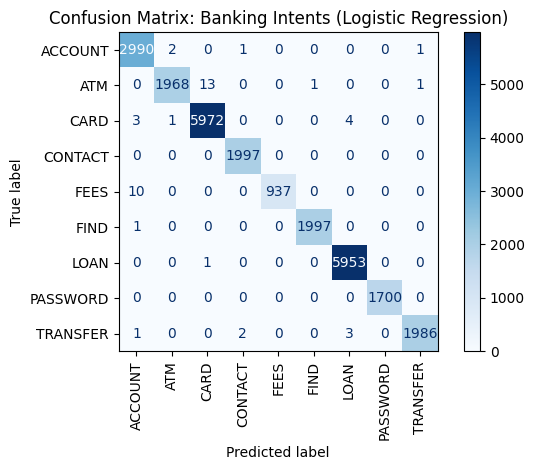

Query: I want to close my account | Prediction: ACCOUNT


In [11]:
# 2. Setup
encoder = SentenceTransformer('all-MiniLM-L6-v2')
le = LabelEncoder()


# 2. Inside the Training/Loading block
if os.path.exists(MODEL_PATH):
    lr_clf = joblib.load(MODEL_PATH)
    le = joblib.load(LABEL_ENCODER_PATH)
    y_encoded = np.load(Y_ENCODED_PATH) # Load the labels
    print("Model and labels loaded from cache.")
else:
    print("Training Logistic Regression...")
    X = encoder.encode(dataset['instruction'])
    y_encoded = le.fit_transform(dataset['category'])
    
    lr_clf = LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=-1)
    lr_clf.fit(X, y_encoded)
    
    # Save everything
    joblib.dump(lr_clf, MODEL_PATH)
    joblib.dump(le, LABEL_ENCODER_PATH)
    np.save(Y_ENCODED_PATH, y_encoded) # Save labels as numpy array
    print("Model trained and cached.")

# 4. Generate Confusion Matrix
print("Generating Confusion Matrix...")
X_val = encoder.encode(dataset['instruction'])
y_pred = lr_clf.predict(X_val)

cm = confusion_matrix(y_encoded, y_pred)

# Plotting
plt.figure(figsize=(15, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', values_format='d')
plt.title("Confusion Matrix: Banking Intents (Logistic Regression)")
plt.tight_layout()
plt.show()

# 5. Quick Test
query = "I want to close my account"
pred_idx = lr_clf.predict(encoder.encode([query]))[0]
print(f"Query: {query} | Prediction: {le.inverse_transform([pred_idx])[0]}")

In [12]:
# 5. Quick Test
query = "I have to activate an Visa online, how can I do it?"
pred_idx = lr_clf.predict(encoder.encode([query]))[0]
print(f"Query: {query} | Prediction: {le.inverse_transform([pred_idx])[0]}")

Query: I have to activate an Visa online, how can I do it? | Prediction: CARD


In [13]:
# 1. Get predictions for the ENTIRE dataset
X_all = encoder.encode(dataset['instruction'])
y_all_pred = lr_clf.predict(X_all)

# 2. Identify mismatch indices
# y_encoded contains all true labels, y_all_pred contains all predictions
mismatched_indices = np.where(y_encoded != y_all_pred)[0]

print(f"Total records: {len(dataset)}")
print(f"Total mismatches found: {len(mismatched_indices)}")

# 3. Create a clean report
mismatched_data = []
for idx in mismatched_indices:
    mismatched_data.append({
        "instruction": dataset['instruction'][idx],
        "actual": le.inverse_transform([y_encoded[idx]])[0],
        "predicted": le.inverse_transform([y_all_pred[idx]])[0]
    })

df_errors = pd.DataFrame(mismatched_data)

Total records: 25545
Total mismatches found: 45


In [14]:
df_errors

,instruction,actual,predicted
0,my amex was stolen could ublocm it,CARD,ATM
1,i got to cancel a credit czrd could i get some...,CARD,LOAN
2,"I need to cancel a credit care, could I get so...",CARD,LOAN
3,i dont want my maex help me to cancel it,CARD,LOAN
4,I want help to cancel an mAex,CARD,LOAN
5,I don't want my iVsa,CARD,ACCOUNT
6,how to cancel a moirtgage,LOAN,CARD
7,i have made a mistake i need help to cancel a ...,TRANSFER,LOAN
8,I have to cancel a tgransfer,TRANSFER,LOAN
9,could uhelp me cancel a traansfer,TRANSFER,LOAN


### Data Augmentation

In [28]:
import nlpaug.augmenter.char as nac

# 1. Define the augmenter
# aug_char_max=1 means only 1 typo per sentence (keeps it realistic)
aug = nac.KeyboardAug(aug_char_max=1) 

# 2. Augment the failed records
new_rows = []
for index, row in df_errors.iterrows():
    instruction = row['instruction']
    actual_intent = row['actual'] # Using the correct label
    
    # Generate 2 variations per error
    aug_texts = aug.augment(instruction, n=2) 
    
    for text in aug_texts:
        new_rows.append({
            "instruction": text, 
            "category": actual_intent # This ensures the model learns the typo = correct intent
        })

In [30]:
dataset_list = list(dataset)
dataset_list.extend(new_rows)

In [32]:
# 4. Re-train (This will use the expanded dataset)
print(f"Training on {len(dataset_list)} records (including synthetic typos)...")
X = encoder.encode([d['instruction'] for d in dataset_list])
y_encoded = le.fit_transform([d['category'] for d in dataset_list])

lr_clf = LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=-1)
lr_clf.fit(X, y_encoded)

# Save the new model
joblib.dump(lr_clf, MODEL_PATH)
print("Model re-trained with augmented data!")

Training on 25635 records (including synthetic typos)...


c:\Users\vncpyy7h\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model re-trained with augmented data!


In [35]:
len(y_encoded)

25635

In [37]:
# 1. Re-encode and predict using your UPDATED lr_clf
# We re-run this because the model has new knowledge now
X_all_updated = encoder.encode(dataset['instruction'])
y_all_pred_updated = lr_clf.predict(X_all_updated)
y_encoded = le.fit_transform(dataset['category'])

# 2. Identify mismatch indices for the updated model
mismatched_indices_after = np.where(y_encoded != y_all_pred_updated)[0]

print(f"Total records: {len(dataset)}")
print(f"Mismatches AFTER augmentation: {len(mismatched_indices_after)}")

# 3. Create the report
mismatched_data_after = []
for idx in mismatched_indices_after:
    mismatched_data_after.append({
        "instruction": dataset['instruction'][idx],
        "actual": le.inverse_transform([y_encoded[idx]])[0],
        "predicted": le.inverse_transform([y_all_pred_updated[idx]])[0]
    })

# Rename as 'errors_after_augmentation'
errors_after_augmentation = pd.DataFrame(mismatched_data_after)

Total records: 25545
Mismatches AFTER augmentation: 25


### Enhanced Sentece Transfomer

In [47]:
# File Paths
DATASET_PATH = "./banking_dataset_cache"
MODEL_PATH = "./intent_classification_lr_L12_model.pkl"
LABEL_ENCODER_PATH = "./label_encoder.pkl"
Y_ENCODED_PATH = "./y_encoded.npy"
X_ENCODED_PATH = "./X_encoded.npy" # Cache the vectors too!

# 1. Load Dataset
if os.path.exists(DATASET_PATH):
    dataset = load_from_disk(DATASET_PATH)
else:
    dataset = load_dataset("bitext/Bitext-retail-banking-llm-chatbot-training-dataset", split="train")
    dataset.save_to_disk(DATASET_PATH)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Training Logistic Regression...


Batches:   0%|          | 0/400 [00:00<?, ?it/s]

Encoding took 351.54 seconds.


c:\Users\vncpyy7h\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fitting took 22.38 seconds.
Model, labels, and embeddings cached.
Generating Confusion Matrix...


<Figure size 1500x1500 with 0 Axes>

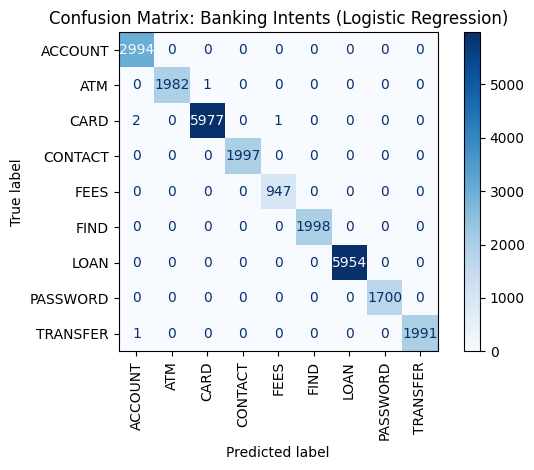

Query: I want to close my account | Prediction: ACCOUNT


In [48]:
# 2. Setup
encoder = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
le = LabelEncoder()

# 3. Train or Load Model
if os.path.exists(MODEL_PATH) and os.path.exists(X_ENCODED_PATH):
    lr_clf = joblib.load(MODEL_PATH)
    le = joblib.load(LABEL_ENCODER_PATH)
    y_encoded = np.load(Y_ENCODED_PATH)
    X = np.load(X_ENCODED_PATH)
    print("Model, labels, and embeddings loaded from cache.")
else:
    print("Training Logistic Regression...")
    
    # Timing Encoding
    start_enc = time.time()
    # Adding show_progress_bar=True for tqdm
    X = encoder.encode(dataset['instruction'], batch_size=64, show_progress_bar=True)
    print(f"Encoding took {time.time() - start_enc:.2f} seconds.")
    
    y_encoded = le.fit_transform(dataset['category'])
    
    # Timing Fitting
    start_fit = time.time()
    lr_clf = LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=-1)
    lr_clf.fit(X, y_encoded)
    print(f"Fitting took {time.time() - start_fit:.2f} seconds.")
    
    # Save everything
    joblib.dump(lr_clf, MODEL_PATH)
    joblib.dump(le, LABEL_ENCODER_PATH)
    np.save(Y_ENCODED_PATH, y_encoded)
    np.save(X_ENCODED_PATH, X) # Cache the vectors!
    print("Model, labels, and embeddings cached.")

# 4. Generate Confusion Matrix
print("Generating Confusion Matrix...")
# We use the cached X (which is X_all)
y_pred = lr_clf.predict(X)

cm = confusion_matrix(y_encoded, y_pred)
# Plotting
plt.figure(figsize=(15, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', values_format='d')
plt.title("Confusion Matrix: Banking Intents (Logistic Regression)")
plt.tight_layout()
plt.show()

# 5. Quick Test
query = "I want to close my account"
pred_idx = lr_clf.predict(encoder.encode([query]))[0]
print(f"Query: {query} | Prediction: {le.inverse_transform([pred_idx])[0]}")